# 03 — What actually drives the price?

Notebook 02 compared one thing at a time. The problem: central listings are
also more often entire homes, and entire homes cost more **anywhere**. A
regression looks at everything at once — each coefficient is the effect of
one factor **while the others are held fixed**.

**Target: log(price)**, not price. Prices are right-skewed, and on the log
scale each coefficient turns into a simple **percentage effect** — which is
how people talk about prices anyway.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import config as cfg
from src import cleaning

sns.set_theme(style="whitegrid", palette="colorblind")
np.random.seed(cfg.SEED)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_csv(cfg.CLEAN_FILE)

# Features: what the listing is, where it is, and simple activity numbers.
X = pd.DataFrame({
    "is_private_room": (df["room_type"] == "Private room").astype(int),
    "is_other_room": df["room_type"].isin(["Shared room", "Hotel room"]).astype(int),
    "is_central": df["is_central"].astype(int),
    "minimum_nights": df["minimum_nights"],
    "number_of_reviews": df["number_of_reviews"],
    "availability_365": df["availability_365"],
    "host_listings": df["calculated_host_listings_count"],
})
y = np.log(df["price"])

# a few listings have no host data - drop those rows
ok = X.notna().all(axis=1)
X, y = X[ok], y[ok]
print(f"{len(X):,} listings, {X.shape[1]} features")

6,923 listings, 7 features


The two room-type columns are 0/1 flags. When both are 0, the listing is an
entire home — so every coefficient reads as "compared to an entire home".

In [3]:
# Train/test split: fit on 75%, judge on the 25% the model never saw.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=cfg.SEED)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print(f"R² on training data: {r2_score(y_train, model.predict(X_train)):.2f}")
print(f"R² on test data    : {r2_score(y_test, pred):.2f}")

R² on training data: 0.37
R² on test data    : 0.37


Train and test R² are almost equal → the model is not overfitting.

The R² itself is moderate — and honestly so: this file has **no flat size,
no amenities, no review scores**, all obvious price drivers. A model without
them cannot explain most of the variation, and pretending otherwise would be
a red flag, not an achievement.

In [4]:
# Coefficients, converted from log units into % effects on price
coefs = pd.DataFrame({
    "coefficient": model.coef_,
    "effect_on_price": [f"{(np.exp(b) - 1) * 100:+.1f}%" for b in model.coef_],
}, index=X.columns)
coefs.round(4)

,coefficient,effect_on_price
is_private_room,-0.6241,-46.4%
is_other_room,-0.7102,-50.8%
is_central,0.1302,+13.9%
minimum_nights,-0.0265,-2.6%
number_of_reviews,-0.0004,-0.0%
availability_365,0.0004,+0.0%
host_listings,0.0021,+0.2%


How to read one line: `is_central = +0.13` means a central listing costs
about **exp(0.13) − 1 ≈ 14% more**, with room type and everything else held
fixed. The tiny coefficients (reviews, availability) are per-unit effects —
per one review, per one day — so they look small but act over big ranges.

In [5]:
b_private = coefs.loc["is_private_room", "coefficient"]
b_central = coefs.loc["is_central", "coefficient"]

raw_gap = df.loc[df["is_central"], "price"].mean() / df.loc[~df["is_central"], "price"].mean() - 1

print(f"entire home vs private room: {(np.exp(-b_private) - 1) * 100:.0f}% more expensive")
print()
print(f"central premium, raw            : {raw_gap:.0%}")
print(f"central premium, after controls : {(np.exp(b_central) - 1) * 100:.1f}%")

entire home vs private room: 87% more expensive

central premium, raw            : 17%
central premium, after controls : 13.9%


This is the notebook's main result. The raw central gap was ~17%, but part
of it was just the room-type mix. Holding room type fixed, **location itself
is worth about 14%** — that is the number a host or investor should use.

In [6]:
# How wrong is a typical prediction, in everyday terms?
mae_log = mean_absolute_error(y_test, pred)
print(f"typical prediction is off by about {(np.exp(mae_log) - 1) * 100:.0f}%")

typical prediction is off by about 43%


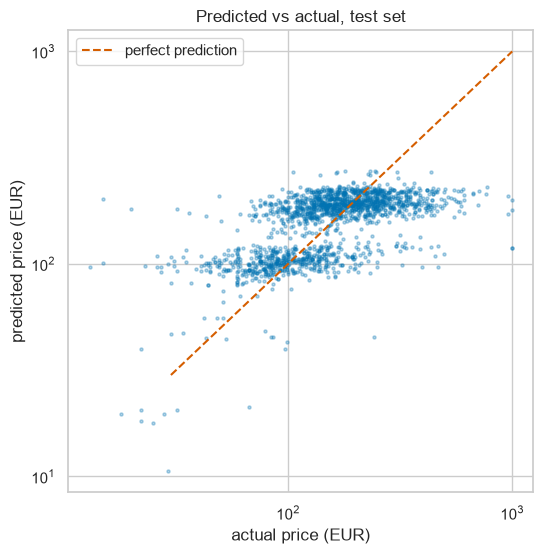

In [7]:
# Predicted vs actual on the test set - a healthy model hugs the red line.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.exp(y_test), np.exp(pred), s=5, alpha=0.3)
lims = [30, 1000]
ax.plot(lims, lims, "r--", label="perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("actual price (EUR)"); ax.set_ylabel("predicted price (EUR)")
ax.set_title("Predicted vs actual, test set")
ax.legend()
fig.savefig(cfg.FIGURES_DIR / "03_predicted_vs_actual.png", dpi=150, bbox_inches="tight")

## What I found

1. Test R² = __, same as training → no overfitting.
2. An entire home costs about __% more than a private room, everything else
   held fixed.
3. The central premium is __% raw, but __% after controlling for room type —
   so part of the "location effect" was really the property mix.
4. A typical prediction is off by ~__% — fine for understanding the market,
   not for pricing a single flat.

**What this model cannot say:** these are associations, not causes, and the
biggest price drivers (size, quality, photos) are simply not in the file.